In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv(
    "../data/processed/failure_train.csv",
    parse_dates=["snapshot_date"]
)

validation = pd.read_csv(
    "../data/processed/failure_validation.csv",
    parse_dates=["snapshot_date"]
)

test = pd.read_csv(
    "../data/processed/failure_test.csv",
    parse_dates=["snapshot_date"]
)

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (72000, 14)
Validation: (12000, 14)
Test: (7000, 14)


In [2]:
feature_columns = [
    "asset_age_years",
    "condition_score",
    "criticality",
    "usage_factor",
    "weather_stress",
    "historical_failure_count",
    "historical_downtime_hours",
    "days_since_last_failure"
]

target_column = "failure_within_30_days"

In [3]:
X_train = train[feature_columns]
y_train = train[target_column]

X_validation = validation[feature_columns]
y_validation = validation[target_column]

X_test = test[feature_columns]
y_test = test[target_column]

In [4]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)

X_validation_imputed = imputer.transform(X_validation)

X_test_imputed = imputer.transform(X_test)

In [5]:
from sklearn.tree import DecisionTreeClassifier

In [6]:
decision_tree = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

In [7]:
decision_tree.fit(
    X_train_imputed,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are co

In [8]:
y_pred = decision_tree.predict(
    X_test_imputed
)

In [9]:
y_probability = decision_tree.predict_proba(
    X_test_imputed
)[:, 1]

In [10]:
y_pred

array([0, 0, 1, ..., 0, 0, 0], shape=(7000,))

In [11]:
y_probability

array([0.        , 0.        , 0.61263459, ..., 0.        , 0.        ,
       0.        ], shape=(7000,))

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [13]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_probability))

Accuracy : 0.43814285714285717
Precision: 0.008111533586818757
Recall   : 0.6153846153846154
F1 Score : 0.016012009006755066
ROC-AUC  : 0.5690182011425535


In [14]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[3035 3913]
 [  20   32]]


In [15]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.44      0.61      6948
           1       0.01      0.62      0.02        52

    accuracy                           0.44      7000
   macro avg       0.50      0.53      0.31      7000
weighted avg       0.99      0.44      0.60      7000



In [16]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        0,  # replace with your Logistic Regression result
        accuracy_score(y_test, y_pred)
    ],
    "Precision": [
        0,  # replace
        precision_score(y_test, y_pred, zero_division=0)
    ],
    "Recall": [
        0,  # replace
        recall_score(y_test, y_pred, zero_division=0)
    ],
    "F1": [
        0,  # replace
        f1_score(y_test, y_pred, zero_division=0)
    ],
    "ROC_AUC": [
        0,  # replace
        roc_auc_score(y_test, y_probability)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.000000,0.000000,0.000000,0.000000,0.000000
1,Decision Tree,0.438143,0.008112,0.615385,0.016012,0.569018


In [17]:
importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": decision_tree.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
1,condition_score,0.373502
3,usage_factor,0.191061
4,weather_stress,0.168942
0,asset_age_years,0.149883
7,days_since_last_failure,0.067092
6,historical_downtime_hours,0.027627
2,criticality,0.021894
5,historical_failure_count,0.000000


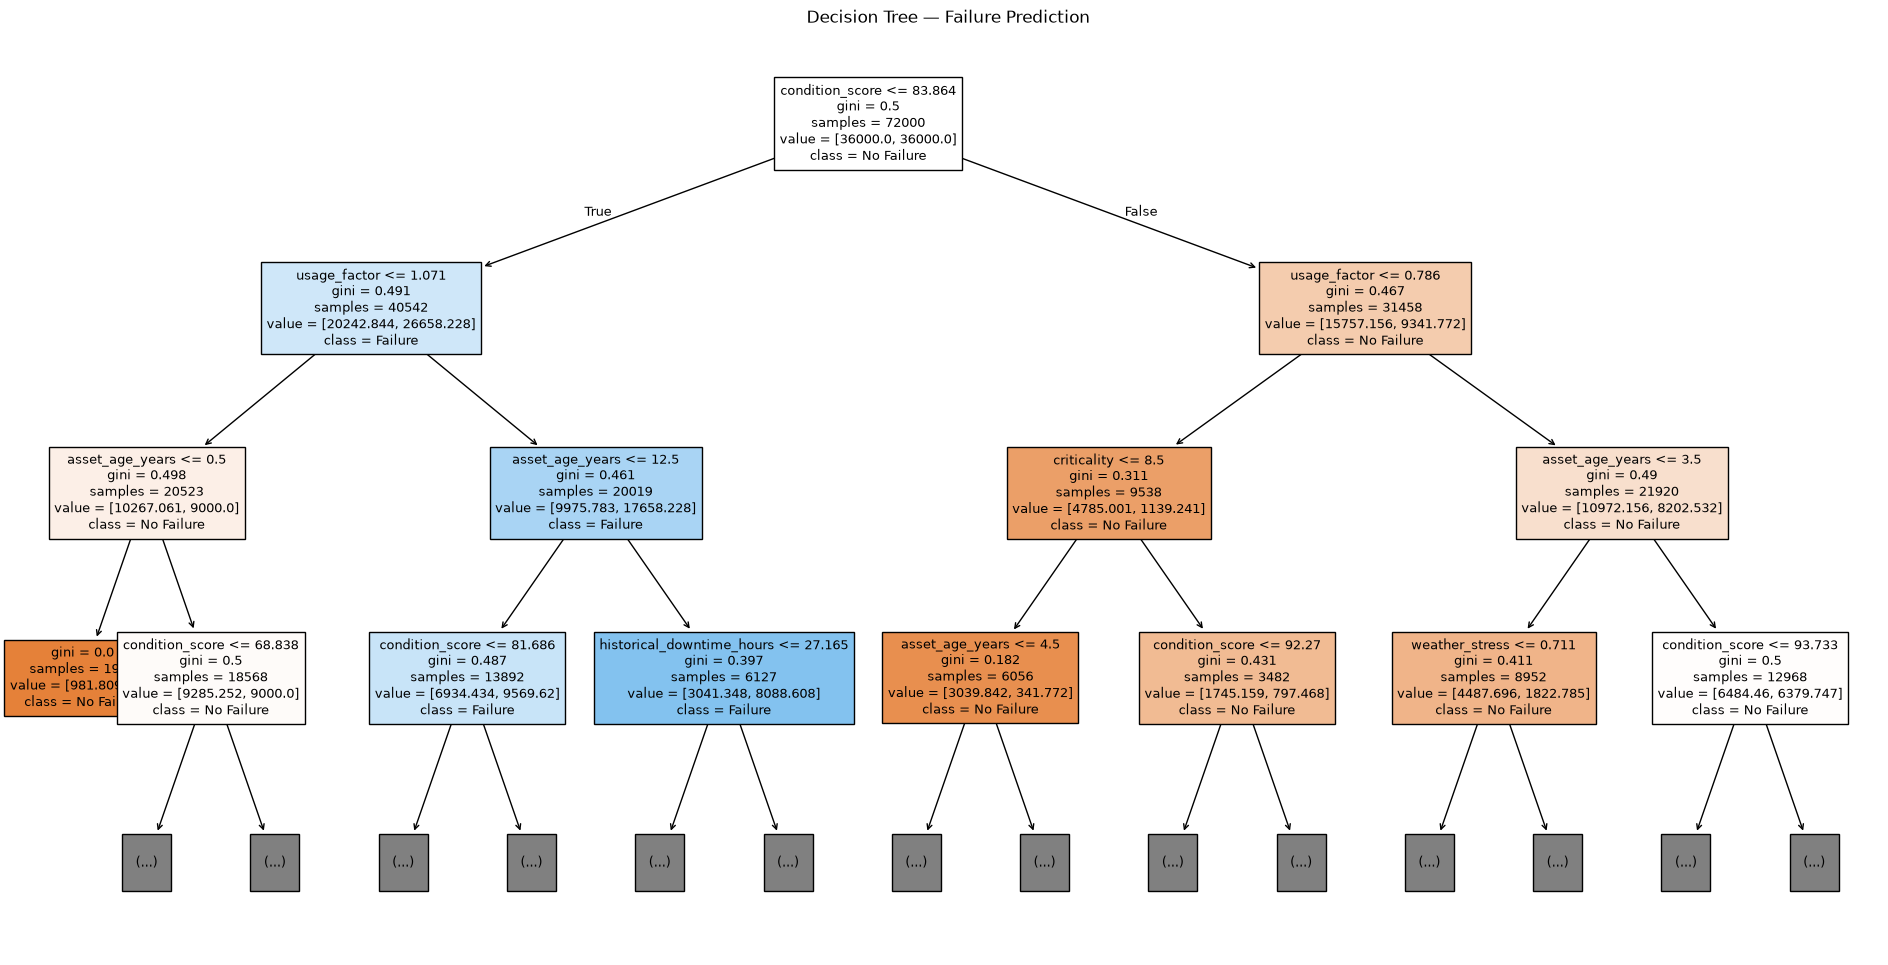

In [18]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))

plot_tree(
    decision_tree,
    feature_names=feature_columns,
    class_names=["No Failure", "Failure"],
    filled=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree — Failure Prediction")
plt.show()

In [19]:
max_depth=3

In [20]:
max_depth=6


In [21]:
train_pred = decision_tree.predict(
    X_train_imputed
)

test_pred = decision_tree.predict(
    X_test_imputed
)

print(
    "Training F1:",
    f1_score(
        y_train,
        train_pred,
        zero_division=0
    )
)

print(
    "Test F1:",
    f1_score(
        y_test,
        test_pred,
        zero_division=0
    )
)

Training F1: 0.015638575152041704
Test F1: 0.016012009006755066


In [22]:
validation_pred = decision_tree.predict(
    X_validation_imputed
)

validation_probability = decision_tree.predict_proba(
    X_validation_imputed
)[:, 1]

In [23]:
print(
    "Validation F1:",
    f1_score(
        y_validation,
        validation_pred,
        zero_division=0
    )
)

print(
    "Validation ROC-AUC:",
    roc_auc_score(
        y_validation,
        validation_probability
    )
)

Validation F1: 0.012262415695892091
Validation ROC-AUC: 0.6381259867476797


In [24]:
tree_predictions = test[
    [
        "asset_id",
        "section_id",
        "department",
        "asset_type",
        "snapshot_date",
        "condition_score",
        "criticality",
        "historical_failure_count",
        "failure_within_30_days"
    ]
].copy()

tree_predictions["failure_probability"] = y_probability

tree_predictions["predicted_failure"] = y_pred

In [25]:
tree_predictions = tree_predictions.sort_values(
    "failure_probability",
    ascending=False
)

In [26]:
tree_predictions.head(20)

,asset_id,section_id,department,asset_type,snapshot_date,condition_score,criticality,historical_failure_count,failure_within_30_days,failure_probability,predicted_failure
4252,ASSET00608,BPL-RTM-01,TRACTION,OHE,2026-04-01,88.228029,8,2,0,0.959805,1
1353,ASSET00194,NDL-MTJ-01,TRACTION,SECTIONING_POST,2026-03-01,95.239252,10,1,0,0.922717,1
1698,ASSET00243,NDL-MTJ-01,TRACTION,SECTIONING_POST,2026-05-01,94.564027,6,3,0,0.922717,1
6082,ASSET00869,VAD-SRT-01,S&T,AXLE_COUNTER,2026-07-01,95.324069,5,1,0,0.922717,1
2087,ASSET00299,MTJ-AGC-01,TRACTION,TRANSFORMER,2026-02-01,94.567059,8,1,0,0.922717,1
6507,ASSET00930,BPL-RTM-01,TRACTION,TRANSFORMER,2026-05-01,95.592089,10,1,0,0.922717,1
3868,ASSET00553,BPL-RTM-01,TRACTION,SECTIONING_POST,2026-05-01,95.602393,6,2,0,0.922717,1
966,ASSET00139,VAD-SRT-01,S&T,AXLE_COUNTER,2026-01-01,93.860749,9,1,0,0.922717,1
1001,ASSET00144,NDL-MTJ-01,S&T,AXLE_COUNTER,2026-01-01,94.310738,5,2,0,0.922717,1
6567,ASSET00939,BPL-RTM-01,TRACTION,OHE,2026-02-01,94.691841,9,1,0,0.922717,1


In [27]:
tree_predictions.to_csv(
    "../data/predictions/decision_tree_failure_predictions.csv",
    index=False
)